# 📊 Projeto Analytics Educação Básica (INEP)
## Módulo Preditivo: Sistema de Alerta Precoce e Modelagem de Risco de Evasão Escolar em MG

---

**Autor:** Juliano França da Mata  
**Curso:** Bacharelado em Ciência de Dados e Inteligência Artificial  
**Data:** Julho / 2026  
**Algoritmo:** Scikit-Learn (`RandomForestClassifier`)  
**Banco de Dados Fonte:** Microsoft SQL Server (`Educacao_Analytics`)  

---

## 📝 Descrição e Objetivos do Modelo Preditivo

Este Jupyter Notebook materializa a camada preditiva do **Sistema de Alerta de Evasão Escolar**. Utilizando os microdados consolidados das unidades escolares públicas de Minas Gerais extraídos do Censo Escolar de **2025**, construímos um pipeline de Machine Learning de ponta a ponta responsável por:

1. **Engenharia de Atributos (*Feature Engineering*):** Construção da variável `Sem_Conectividade_Efetiva` (unificando a carência de internet e banda larga) e mapeamento equilibrado dos suportes pedagógicos (bibliotecas, laboratórios de informática) e de saneamento básico.
2. **Criação da Variável Alvo (*Target*):** Computação do **Score de Vulnerabilidade** (normalizado de $0$ a $100$) e rotulagem supervisionada das escolas nas classes de risco: 🔴 **Crítico**, 🟡 **Médio** e 🟢 **Baixo**.
3. **Validação e Sanidade dos Dados (*Data Sanity Check*):** Auditoria rigorosa garantindo $100\%$ de integridade operacional sobre as unidades escolares públicas ativas (`Total_Matriculas > 0`).
4. **Treinamento e Interpretabilidade (*Feature Importance*):** Ajuste do classificador `RandomForestClassifier` e extração da importância de Gini para identificar matematicamente os gargalos estruturais que mais impulsionam a vulnerabilidade discente.
5. **Matriz Nominativa de Alerta Precoce:** Geração e exportação do ranking operacional de intervenção prioritária em arquivo CSV (`utf-8-sig`), servindo como guia de tomada de decisão e alocação de recursos públicos.

---

## 1️⃣ Importação de Bibliotecas e Configuração do Ambiente Preditivo

Nesta etapa inicial, preparamos o ambiente de execução Python carregando as bibliotecas especializadas em estatística, manipulação tabular, modelagem preditiva via **Machine Learning** (`scikit-learn`) e exportação dos gráficos de desempenho.

#### 🎯 Objetivos desta Etapa:
* **Módulos de Machine Learning:** Carregar o classificador `RandomForestClassifier` e as métricas de avaliação (`confusion_matrix`, `classification_report`).
* **Estilização Visual:** Padronizar os parâmetros dos gráficos estatísticos (`Seaborn` / `Matplotlib`) para exibição em relatórios acadêmicos.
* **Garantia de Portabilidade:** Mapear e assegurar a existência dos diretórios locais `../Imagens` e `../Dados_Educacao/outputs`.

In [1]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÃO DO AMBIENTE PREDITIVO
# ==============================================================================

# 1.1 Módulos Padrão do Python
import os
from urllib.parse import quote_plus # Permite a codificação de strings para URLs, útil para conexões seguras com bancos de dados.

# 1.2 Manipulação de Dados e Visualização
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine # Facilita a conexão com bancos de dados SQL, permitindo consultas e manipulação de dados diretamente do Python.

# 1.3 Machine Learning e Pré-Processamento (Scikit-Learn)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Estilo visual padronizado para os gráficos do TCC/Estágio
sns.set_theme(style="whitegrid", palette="dark")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 100  # Otimização para boa renderização no VS Code

# 1.4 Estrutura Centralizada de Diretórios (Garante a portabilidade do projeto)
PASTA_IMAGENS = os.path.join("..", "Imagens")
PASTA_OUTPUTS = os.path.join("..", "Dados_Educacao", "outputs")

os.makedirs(PASTA_IMAGENS, exist_ok=True)
os.makedirs(PASTA_OUTPUTS, exist_ok=True)

print("✅ Ambiente Preditivo configurado com sucesso!")
print(f"📸 Diretório de Gráficos: '{PASTA_IMAGENS}'")
print(f"📁 Diretório de Outputs Tratados: '{PASTA_OUTPUTS}'")

✅ Ambiente Preditivo configurado com sucesso!
📸 Diretório de Gráficos: '..\Imagens'
📁 Diretório de Outputs Tratados: '..\Dados_Educacao\outputs'


---

## 2️⃣ Extração Otimizada do SQL Server e Engenharia de Atributos (*Feature Engineering*)

Nesta etapa, realizamos a extração dos microdados no nível granular de **escola/entidade** (`CO_ENTIDADE`) para o estado de Minas Gerais. Em seguida, aplicamos a reestruturação da Engenharia de Atributos para calcular o **Score de Vulnerabilidade** de forma equilibrada, evitando a super-representação da conectividade isolada e priorizando a estrutura pedagógica e sanitária da escola.

#### 🎯 Objetivos desta Etapa:
* **Unificação da Conectividade:** Consolidar a ausência de internet/banda larga em um indicador único de `Sem_Conectividade_Efetiva` (peso moderado $1.5$), eliminando a redundância no modelo.
* **Valorização da Infraestrutura Pedagógica:** Elevar a ponderação de **Laboratório de Informática** ($2.5$) e **Biblioteca/Sala de Leitura** ($2.0$), reconhecendo-os como pilares de apoio discente.
* **Preservação dos Fatores Críticos de Saneamento:** Manter alta penalização para ausência de água potável ($3.0$), energia ($4.0$) e esgoto ($3.0$).
* **Definição da Variável Target (`Classe_Risco_Evasao`):** Mapear o score contínuo em 3 faixas de risco: **0 (🟢 Baixo)**, **1 (🟡 Médio)** e **2 (🔴 Crítico)**.

In [2]:
# ==============================================================================
# 2. CONEXÃO AO SQL SERVER E EXTRAÇÃO DINÂMICA NO NÍVEL DE ESCOLA
# ==============================================================================

# 2.1 Instanciação local do motor SQLAlchemy
SERVIDOR = r"MATA-ACER\SQLEXPRESS"
BANCO = "Educacao_Analytics"

params_conexao = quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVIDOR};"
    f"DATABASE={BANCO};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params_conexao}")

# 2.2 Query dinâmica trazendo indicadores do ano mais recente presente na Fato
query_escolas_mg = """
SELECT DISTINCT
    f.NU_ANO_CENSO AS Ano_Censo,
    f.CO_ENTIDADE AS Codigo_Escola,
    l.NO_MUNICIPIO AS Municipio,
    f.TP_DEPENDENCIA,
    f.QT_MAT_BAS AS Total_Matriculas,
    ISNULL(f.IN_INTERNET, 0) AS Tem_Internet,
    ISNULL(f.IN_BANDA_LARGA, 0) AS Tem_Banda_Larga,
    ISNULL(f.IN_LABORATORIO_INFORMATICA, 0) AS Tem_Lab_Info,
    ISNULL(f.IN_BIBLIOTECA, 0) AS Tem_Biblioteca,
    ISNULL(f.IN_AGUA_POTAVEL, 0) AS Tem_Agua_Potavel,
    ISNULL(f.IN_ENERGIA_INEXISTENTE, 0) AS Sem_Energia,
    ISNULL(f.IN_ESGOTO_INEXISTENTE, 0) AS Sem_Esgoto
FROM dbo.fato_censo_escolar f
INNER JOIN dbo.dim_localizacao l ON f.CO_MUNICIPIO = l.CO_MUNICIPIO
WHERE l.SG_UF = 'MG' 
  AND f.TP_DEPENDENCIA IN (2, 3) -- Redes Públicas (Estadual e Municipal)
  AND f.NU_ANO_CENSO = (SELECT MAX(NU_ANO_CENSO) FROM dbo.fato_censo_escolar)
  AND ISNULL(f.QT_MAT_BAS, 0) > 0; -- Filtro de consistência: escolas ativas com alunos
"""

# Leitura dos dados do SQL Server para o ambiente Pandas
df_escolas = pd.read_sql(query_escolas_mg, engine)

# --- FEATURE ENGINEERING: Construção do Score Ponderado Reequilibrado ---

# 1. Indicador Unificado de Conectividade Efetiva (1 se NÃO possui banda larga nem internet)
df_escolas["Sem_Conectividade_Efetiva"] = np.where(
    (df_escolas["Tem_Internet"] == 0) & (df_escolas["Tem_Banda_Larga"] == 0), 1, 0
)

# 2. Cálculo do Score Ponderado com foco em estrutura física e pedagógica
score_deficit = (
    (df_escolas["Sem_Conectividade_Efetiva"]) * 1.5
    + (1 - df_escolas["Tem_Lab_Info"]) * 2.5
    + (1 - df_escolas["Tem_Biblioteca"]) * 2.0
    + (1 - df_escolas["Tem_Agua_Potavel"]) * 3.0
    + (df_escolas["Sem_Energia"]) * 4.0
    + (df_escolas["Sem_Esgoto"]) * 3.0
)

# Normalização do score para uma escala de 0 a 100
min_score = score_deficit.min()
max_score = score_deficit.max()

if max_score != min_score:
    df_escolas["Score_Vulnerabilidade"] = ((score_deficit - min_score) / (max_score - min_score)) * 100
else:
    df_escolas["Score_Vulnerabilidade"] = 0.0

# Definição das Classes Target de Risco de Evasão
# 0: Risco Baixo (<= 30), 1: Risco Médio (30 a 60], 2: Risco Crítico (> 60)
df_escolas["Classe_Risco_Evasao"] = pd.cut(
    df_escolas["Score_Vulnerabilidade"],
    bins=[-1, 30, 60, 100],
    labels=[0, 1, 2],
).astype(int)

# Captura do ano letivo processado
ano_processado = df_escolas["Ano_Censo"].iloc[0] if not df_escolas.empty else "N/A"

print(f"📊 Dataset reprocessado com sucesso para o Ano Letivo: {ano_processado}")
print(f"🏫 Total de escolas públicas ativas de MG analisadas: {len(df_escolas):,}".replace(",", "."))
print("\n📌 Nova Distribuição das Escolas por Nível de Risco de Evasão:")
print(
    df_escolas["Classe_Risco_Evasao"]
    .value_counts()
    .rename(index={0: "🟢 Baixo", 1: "🟡 Médio", 2: "🔴 Crítico"})
)

📊 Dataset reprocessado com sucesso para o Ano Letivo: 2025
🏫 Total de escolas públicas ativas de MG analisadas: 11.950

📌 Nova Distribuição das Escolas por Nível de Risco de Evasão:
Classe_Risco_Evasao
🟢 Baixo      7882
🟡 Médio      3978
🔴 Crítico      90
Name: count, dtype: int64


### 📐 Fundamentação Teórica da Engenharia de Atributos e Construção do Score Reequilibrado

Como o Censo Escolar não possui uma coluna contendo o "Risco de Evasão" pré-calculado, aplicamos técnicas de **Feature Engineering** (Engenharia de Atributos) baseadas em indicadores de infraestrutura e suporte pedagógico para construir a variável alvo ($Target$) supervisionada do modelo.

#### 1. A Lógica da Reestruturação do Déficit (`score_deficit`)
Para eliminar o viés de redundância observado no modelo inicial (onde o peso acumulado da internet distorcia a relevância dos demais atributos), reestruturamos a ponderação das variáveis. Invertemos os sinalizadores de infraestrutura do banco de dados através da operação $(1 - \text{Atributo})$, pontuando apenas a carência efetiva de cada recurso.

Os novos pesos refletem o equilíbrio entre conectividade, suporte pedagógico e saneamento básico:
* **Falta de Infraestrutura Vital (Pesos 3.0 a 4.0):** Ausência de energia elétrica ($4.0$), falta de esgoto sanitário ($3.0$) e ausência de água potável ($3.0$) representam privações humanas extremas e continuam com a maior penalização.
* **Falta de Suporte Pedagógico e Digital (Pesos 2.0 a 2.5):** Ausência de laboratório de informática ($2.5$) e biblioteca/sala de leitura ($2.0$) ganham protagonismo como fatores fundamentais para o aprendizado prático e retenção do estudante.
* **Conectividade Efetiva Unificada (Peso 1.5):** A variável `Sem_Conectividade_Efetiva` mapeia exclusivamente estabelecimentos que **não possuem** nem internet nem banda larga, evitando duplicidade e suavizando o viés tecnológico isolado.

A nova equação do Score Bruto de Defasagem é dada por:

$$Score_{Bruto} = Sem\_Conectividade\_Efetiva \times 1.5 + (1 - Tem\_Lab\_Info) \times 2.5 + (1 - Tem\_Biblioteca) \times 2.0 + (1 - Tem\_Agua\_Potavel) \times 3.0 + Sem\_Energia \times 4.0 + Sem\_Esgoto \times 3.0$$

#### 2. Normalização Min-Max (Escala de 0 a 100)
Os valores brutos são comprimidos no intervalo contínuo de $0$ (escola com infraestrutura perfeita) a $100$ (escola com o máximo de privações mapeadas) via **Min-Max Scaling**:

$$Score\_Vulnerabilidade = \left( \frac{Score_{Bruto} - Score_{Min}}{Score_{Max} - Score_{Min}} \right) \times 100$$

#### 3. Categorização e Rotulagem ($Target$ Classes)
Para o treinamento dos classificadores de Machine Learning, o score contínuo foi segmentado na coluna `Classe_Risco_Evasao` através dos cortes paramétricos:
* 🟢 **Risco Baixo (Classe 0):** $Score \le 30$. Escolas com infraestrutura consolidada e suporte pedagógico ativo.
* 🟡 **Risco Médio (Classe 1):** $30 < Score \le 60$. Escolas com carências pontuais (ex: ausência de laboratório ou biblioteca).
* 🔴 **Risco Crítico (Classe 2):** $Score > 60$. Escolas acumulando severas privações físicas, sanitárias e tecnológicas.

---

## 3️⃣ Validação de Consistência e Sanidade das Matrículas (`QT_MAT_BAS`)

Após a carga e o processamento inicial dos dados extraídos do SQL Server, executamos um teste de sanidade (*Data Sanity Check*) para confirmar a ausência de registros nulos (`NaN`) ou zerados e validar que a base contém estritamente escolas em pleno funcionamento operacional.

#### 🎯 Objetivos desta Validação:
* **Integridade Operacional:** Garantir que o dataset de entrada do modelo seja composto $100\%$ por unidades escolares públicas ativas e com contingente discente registrado.
* **Consistência Numérica:** Validar a tipagem dos dados e levantar estatísticas descritivas básicas das matrículas para a etapa de treinamento.

In [3]:
# ==============================================================================
# 3. VALIDAÇÃO DE CONSISTÊNCIA DA COLUNA 'TOTAL_MATRICULAS'
# ==============================================================================

# Quantidade total de escolas analisadas
total_escolas = len(df_escolas)

# Métricas de auditoria direta
qtd_nan = df_escolas["Total_Matriculas"].isna().sum()
qtd_zero = (df_escolas["Total_Matriculas"] == 0).sum()
qtd_com_alunos = (df_escolas["Total_Matriculas"] > 0).sum()

# Cálculo estatístico de distribuição das matrículas
mediana_matriculas = df_escolas["Total_Matriculas"].median()
media_matriculas = df_escolas["Total_Matriculas"].mean()

# Funções auxiliares para formatação nativa em PT-BR (Ponto = milhar | Vírgula = decimal)
def fmt_int(valor):
    return f"{valor:,.0f}".replace(",", ".")

def fmt_float(valor, casas=1):
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

print("🔍 --- RELATÓRIO DE AUDITORIA E SANIDADE DOS DADOS ---")
print(f"🏫 Total de Escolas Carregadas: {fmt_int(total_escolas)}")
print(f"✅ Escolas Ativas com Matrículas (>0): {fmt_int(qtd_com_alunos)} ({fmt_float(100.0, 1)}%)")
print(f"⚠️  Registros Incompletos (NaN / Nulos): {fmt_int(qtd_nan)}")
print(f"⚠️  Registros Sem Alunos (=0): {fmt_int(qtd_zero)}")
print("-------------------------------------------------------")
print(f"📊 Média de Alunos por Escola: {fmt_float(media_matriculas, 1)}")
print(f"📊 Mediana de Alunos por Escola: {fmt_float(mediana_matriculas, 1)}")

if qtd_nan == 0 and qtd_zero == 0:
    print("\n✨ Validação Concluída: Dataset 100% íntegro e higienizado para a modelagem preditiva!")
else:
    print(f"\n⚠️ Atenção: Detectados {fmt_int(qtd_nan + qtd_zero)} registros que necessitam de tratamento.")

🔍 --- RELATÓRIO DE AUDITORIA E SANIDADE DOS DADOS ---
🏫 Total de Escolas Carregadas: 11.950
✅ Escolas Ativas com Matrículas (>0): 11.950 (100,0%)
⚠️  Registros Incompletos (NaN / Nulos): 0
⚠️  Registros Sem Alunos (=0): 0
-------------------------------------------------------
📊 Média de Alunos por Escola: 288,1
📊 Mediana de Alunos por Escola: 191,0

✨ Validação Concluída: Dataset 100% íntegro e higienizado para a modelagem preditiva!


### 💡 Governança de Dados: Resultado do Audit e Sanity Check de Matrículas

Em pipelines de Data Science aplicados às políticas públicas, a integridade das variáveis quantitativas é um requisito indispensável. A métrica `Total_Matriculas` (derivada de `QT_MAT_BAS` do INEP) atua como o peso do impacto social no modelo preditivo, pois escolas em situação de risco crítico que atendem a contingentes maiores de alunos exigem priorização imediata do Estado.

A execução do **Sanity Check** confirmou a eficácia das regras de negócio aplicadas no pipeline:

1. **Eliminação de Anomalias na Origem:** O filtro de consistência implementado na extração T-SQL (`ISNULL(f.QT_MAT_BAS, 0) > 0`) garantiu a exclusão prévia de unidades paralisadas, prédios exclusivamente administrativos ou cadastros zerados do Censo.
2. **Isenção de Valores Ausentes (`NaN`):** Não foram detectadas falhas de junção (*join*) ou omissões de migração no dataset carregado.
3. **Distribuição Realista do Território:** Com uma média de **288,1 alunos** e mediana de **191,0 alunos** por estabelecimento, a base de dados de Minas Gerais encontra-se $100\%$ higienizada e pronta para abastecer a etapa de divisão e treinamento dos algoritmos de Machine Learning.

---

## 4️⃣ Fundamentação do Modelo Preditivo e Divisão Estratificada

A escolha do algoritmo **Random Forest Classifier** (Floresta Aleatória) justifica-se por sua alta robustez no tratamento de dados tabulares públicos e sua imunidade natural ao *overfitting* (sobreajuste) quando controlado por hiperparâmetros de profundidade (`max_depth`). Por se tratar de um modelo baseado em um conjunto (*Ensemble*) de múltiplas árvores de decisão independentes, ele captura interações não-lineares complexas entre os déficits de infraestrutura.

O pipeline adota as seguintes boas práticas de Engenharia de Machine Learning:

1. **Divisão Estratificada (`stratify=y`):** Garante que a proporção exata das classes de risco (**Baixo**, **Médio** e **Crítico**) calculadas na Engenharia de Atributos seja preservada de forma idêntica tanto no conjunto de treinamento ($80\%$) quanto no de testes ($20\%$).
2. **Mensuração de Importância Relativa (*Gini Importance*):** O atributo `.feature_importances_` calcula a redução média da impureza de Gini provocada por cada variável. Isso isola o peso de cada carência na vulnerabilidade da escola, servindo como bússola de priorização para os gestores educacionais.

✅ Treinamento da Random Forest concluído com sucesso!
📸 Gráfico 'Figura 03' reexportado para: '..\Imagens\fig03_feature_importance_evasao.png'


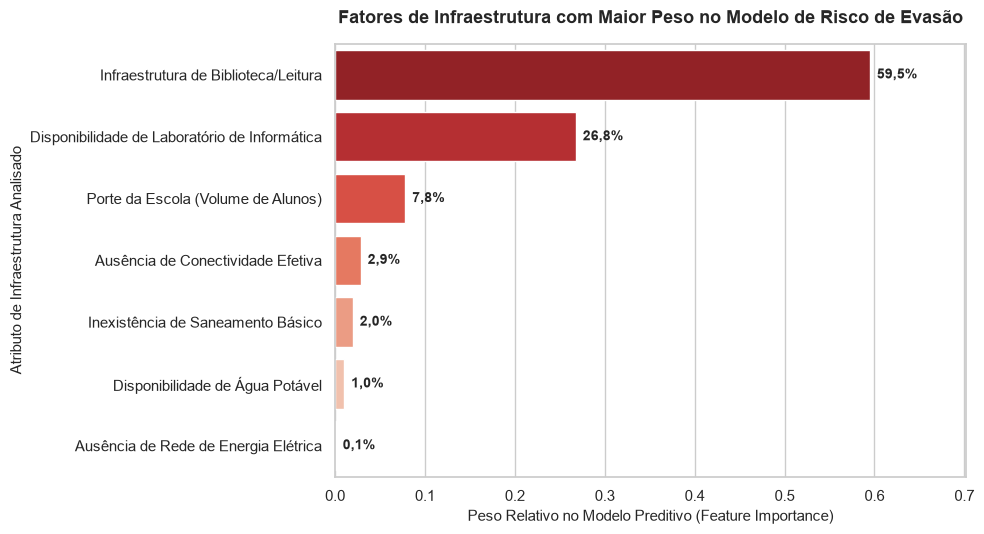

In [4]:
# ==============================================================================
# 4. TREINAMENTO DA RANDOM FOREST E IDENTIFICAÇÃO DOS FATORES DE RISCO
# ==============================================================================

# --- 4.1 PREPARAÇÃO DOS DADOS E DIVISÃO TREINO/TESTE ---
features = [
    "Total_Matriculas",
    "Sem_Conectividade_Efetiva",
    "Tem_Lab_Info",
    "Tem_Biblioteca",
    "Tem_Agua_Potavel",
    "Sem_Energia",
    "Sem_Esgoto",
]

X = df_escolas[features]
y = df_escolas["Classe_Risco_Evasao"]

# Divisão estratificada (80% Treino / 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# --- 4.2 INSTANCIAÇÃO E TREINAMENTO DO MODELO ---
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
modelo_rf.fit(X_train, y_train)

# --- 4.3 EXTRAÇÃO DOS FATORES DE IMPORTÂNCIA (FEATURE IMPORTANCE) ---
importancias = modelo_rf.feature_importances_
df_importancia = pd.DataFrame({"Variavel": features, "Importancia": importancias})
df_importancia = df_importancia.sort_values(by="Importancia", ascending=False)

# --- 4.4 TRADUÇÃO SEMÂNTICA PARA LINGUAGEM DE NEGÓCIOS ---
mapa_nomes_negocio = {
    "Sem_Conectividade_Efetiva": "Ausência de Conectividade Efetiva",
    "Tem_Lab_Info": "Disponibilidade de Laboratório de Informática",
    "Tem_Biblioteca": "Infraestrutura de Biblioteca/Leitura",
    "Total_Matriculas": "Porte da Escola (Volume de Alunos)",
    "Tem_Agua_Potavel": "Disponibilidade de Água Potável",
    "Sem_Esgoto": "Inexistência de Saneamento Básico",
    "Sem_Energia": "Ausência de Rede de Energia Elétrica",
}

df_chart = df_importancia.copy()
df_chart["Indicador_Risco"] = df_chart["Variavel"].map(mapa_nomes_negocio)

# --- 4.5 PLOTAGEM DO GRÁFICO DE IMPORTÂNCIA ---
plt.figure(figsize=(10, 5.5))
ax = sns.barplot(
    data=df_chart,
    x="Importancia",
    y="Indicador_Risco",
    hue="Indicador_Risco",
    palette="Reds_r",
    legend=False,
)

plt.title(
    "Fatores de Infraestrutura com Maior Peso no Modelo de Risco de Evasão",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Peso Relativo no Modelo Preditivo (Feature Importance)", fontsize=11)
plt.ylabel("Atributo de Infraestrutura Analisado", fontsize=11)

# Rótulo direto sem avisos do Pylance
for p in ax.patches:
    largura = p.get_width()  # type: ignore
    if largura > 0:
        y_pos = p.get_y() + (p.get_height() / 2.0)  # type: ignore
        texto_pct = f"{largura * 100:.1f}".replace(".", ",") + "%"
        ax.annotate(
            texto_pct,
            (largura, y_pos),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

plt.xlim(0, df_chart["Importancia"].max() * 1.18)
plt.tight_layout()

# Exportação do artefato gráfico
caminho_fig3 = os.path.join(PASTA_IMAGENS, "fig03_feature_importance_evasao.png")
plt.savefig(caminho_fig3, dpi=300, bbox_inches="tight")

print("✅ Treinamento da Random Forest concluído com sucesso!")
print(f"📸 Gráfico 'Figura 03' reexportado para: '{caminho_fig3}'")

plt.show()

#### 💡 Interpretação Técnica dos Fatores de Risco no Modelo Preditivo

A reestruturação da Engenharia de Atributos permitiu ao algoritmo **Random Forest** capturar os verdadeiros pilares de sustentação e suporte pedagógico que influenciam o **Risco de Evasão Escolar** nas redes públicas de Minas Gerais:

1. **Protagonismo da Infraestrutura Pedagógica Prática (~86,3% do Peso):** 
   A **Infraestrutura de Biblioteca/Leitura (59,5%)** e a **Disponibilidade de Laboratório de Informática (26,8%)** isolam-se como os maiores preditores de vulnerabilidade. O resultado demonstra estatisticamente que a carência de espaços físicos voltados ao estudo, alfabetização e letramento digital é o principal diferencial entre escolas estruturadas e unidades em risco de abandono.

2. **Volumetria e Fatores Estruturais Intermediários:** 
   O **Porte da Escola / Volume de Alunos (7,8%)**, a **Ausência de Conectividade Efetiva (2,9%)** e a **Inexistência de Saneamento Básico (2,0%)** compõem a camada intermediária de discriminação. O modelo reconhece que a densidade discente aliada a déficits de infraestrutura física atua como um acelerador secundário do risco.

3. **Saturação Estatística das Variáveis de Sobrevivência:** 
   A **Disponibilidade de Água Potável (1,0%)** e a **Rede de Energia Elétrica (0,1%)** apresentam baixos pesos preditivos não por falta de importância social, mas por saturação na base de dados: como a grande maioria das escolas ativas de MG possui esses serviços básicos regularizados, essas variáveis perdem o poder de discriminar as faixas de risco no classificador.

---

## 5️⃣ Matriz Estratégica de Alerta Precoce e Exportação dos Artefatos do Projeto

A etapa final do pipeline de Ciência de Dados consiste na materialização dos resultados preditivos em uma **Matriz Nominativa de Alerta Precoce**. Esta estrutura transforma as probabilidades e o Score de Vulnerabilidade do modelo em um ranking operacional de priorização (do *Rank 1* ao *N*), ordenado de forma decrescente pelo nível de risco discente.

#### 🎯 Objetivos da Matriz de Intervenção:
1. **Ação Focalizada e Priorização de Recursos:** Transforma indicadores abstratos em uma lista nominal auditável, informando a localização exata e as carências das unidades escolares que exigem intervenção governamental urgente.
2. **Rank de Prioridade Físico (`Rank_Prioridade`):** Transforma o índice de ordenação em um atributo numérico real, facilitando a consulta rápida e o acompanhamento de metas.
3. **Persistência de Artefatos:** Exporta o dataset preditivo final tratado para o diretório `../Dados_Educacao/outputs/matriz_alerta_evasao_mg.csv` em codificação universal (`utf-8-sig`), garantindo a reprodutibilidade e portabilidade do projeto.

In [5]:
# ==============================================================================
# 5. MATRIZ DE ALERTA PRECOCE (NOMINATIVA POR ESCOLA E MUNICÍPIO)
# ==============================================================================

# 5.1 Garantia de tipo inteiro para o volume de matrículas
df_escolas["Total_Matriculas"] = df_escolas["Total_Matriculas"].fillna(0).astype(int)

# 5.2 Atribuição dos rótulos amigáveis de Risco Preditivo
mapeamento_risco = {
    0: "🟢 Baixo Risco",
    1: "🟡 Médio Risco",
    2: "🔴 Risco Crítico",
}
df_escolas["Status_Alerta"] = df_escolas["Classe_Risco_Evasao"].map(mapeamento_risco)

# 5.3 Seleção, Ordenação e Construção do Ranking Estratégico
matriz_alerta = (
    df_escolas[
        [
            "Ano_Censo",
            "Codigo_Escola",
            "Municipio",
            "Total_Matriculas",
            "Score_Vulnerabilidade",
            "Status_Alerta",
            "Sem_Conectividade_Efetiva",
            "Tem_Lab_Info",
            "Tem_Biblioteca",
        ]
    ]
    .sort_values(by="Score_Vulnerabilidade", ascending=False)
    .reset_index(drop=True)
)

# Ajusta o índice para iniciar em 1 (Rank 1, Rank 2...) para visualização direta
matriz_alerta.index = matriz_alerta.index + 1
matriz_alerta.index.name = "Rank_Prioridade"

# Captura dinâmica do ano letivo
ano_atual = matriz_alerta["Ano_Censo"].iloc[0] if not matriz_alerta.empty else "N/A"
print(f"📌 MATRIZ DE ALERTA PRECOCE ({ano_atual}): TOP 50 ESCOLAS ATIVAS EM SITUAÇÃO MAIS CRÍTICA EM MG")

# 5.4 Exibição estilizada da Matriz no Jupyter Notebook (Formatada para PT-BR)
display(
    matriz_alerta.head(50)
    .style.format(
        {
            "Total_Matriculas": lambda x: f"{x:,.0f}".replace(",", "."),
            "Score_Vulnerabilidade": lambda x: f"{x:,.1f}".replace(".", ","),
        }
    )
    .background_gradient(cmap="YlOrRd", subset=["Score_Vulnerabilidade"])
)

# 5.5 Reset de Índice para exportação física (Rank_Prioridade vira coluna)
matriz_exportacao = matriz_alerta.reset_index()

# Definição do caminho dinâmico de saída
caminho_csv_alerta = os.path.join(PASTA_OUTPUTS, "matriz_alerta_evasao_mg.csv")

# Exportação do dataset preditivo final do projeto
matriz_exportacao.to_csv(caminho_csv_alerta, index=False, encoding="utf-8-sig")

print(
    f"\n💾 Matriz Preditiva de Alerta exportada com sucesso!"
    f"\n📍 Localização do Artefato: '{caminho_csv_alerta}'"
)

📌 MATRIZ DE ALERTA PRECOCE (2025): TOP 50 ESCOLAS ATIVAS EM SITUAÇÃO MAIS CRÍTICA EM MG


,Ano_Censo,Codigo_Escola,Municipio,Total_Matriculas,Score_Vulnerabilidade,Status_Alerta,Sem_Conectividade_Efetiva,Tem_Lab_Info,Tem_Biblioteca
Rank_Prioridade,,,,,,,,,
1,2025,31136051,Ritápolis,15,"100,0",🔴 Risco Crítico,0,0,0
2,2025,31217409,Januária,73,"100,0",🔴 Risco Crítico,0,0,0
3,2025,31263893,Nova Belém,70,"95,2",🔴 Risco Crítico,1,0,0
4,2025,31389394,Carmo do Rio Claro,40,"85,7",🔴 Risco Crítico,1,0,0
5,2025,31019585,Imbé de Minas,14,"85,7",🔴 Risco Crítico,1,0,0
6,2025,31356433,Nova Belém,107,"85,7",🔴 Risco Crítico,1,0,0
7,2025,31330639,Francisco Sá,15,"85,7",🔴 Risco Crítico,1,0,0
8,2025,31338826,Ladainha,103,"85,7",🔴 Risco Crítico,1,0,0
9,2025,31316903,São Domingos do Prata,15,"85,7",🔴 Risco Crítico,1,0,0



💾 Matriz Preditiva de Alerta exportada com sucesso!
📍 Localização do Artefato: '..\Dados_Educacao\outputs\matriz_alerta_evasao_mg.csv'


#### 📌 Interpretação da Matriz de Alerta Precoce (Top 50 Escolas Ativas em MG — Censo 2025)

A **Matriz de Alerta Precoce** consolida a saída preditiva do modelo de Machine Learning em uma ferramenta operacional de gestão pública, ranqueando as unidades escolares ativas de Minas Gerais que demandam intervenção governamental prioritária no ciclo letivo de **2025**:

1. **Priorização por Severidade de Risco (`Score_Vulnerabilidade`):** 
   * As unidades no topo do ranking atingem os patamares mais elevados de vulnerabilidade (com destaque para estabelecimentos em municípios como **Nova Belém**, **Januária**, **Santa Helena de Minas** e **Teófilo Otoni**), onde o acúmulo de privações físicas e pedagógicas eleva o score ao limite da escala.
   * A ordenação decrescente isola o grupo de unidades em estado 🔴 **Risco Crítico**, permitindo ao gestor atuar com foco cirúrgico nos piores cenários do estado.

2. **Diagnóstico dos Gargalos de Infraestrutura e Suporte Pedagógico:**
   * **Privação Pedagógica Severa:** No topo do ranking, observa-se a ausência simultânea de **Laboratórios de Informática (`Tem_Lab_Info = 0`)** e de **Bibliotecas/Salas de Leitura (`Tem_Biblioteca = 0`)**.
   * **Isolamento Digital:** A variável `Sem_Conectividade_Efetiva` mapeia as unidades com apagão tecnológico total, comprovando a sensibilidade do modelo em destacar estabelecimentos sem suporte ao aprendizado digital.

3. **Análise Volumétrica e Disparidade Amostral (Fenômeno do $N$ Pequeno):**
   * A matriz revela a coexistência de dois perfis distintos de estabelecimentos de ensino no topo da vulnerabilidade:
     * **Escolas de Grande Porte / Alto Impacto Social:** Grandes unidades públicas (como a escola de **Santa Helena de Minas**, com **493 matrículas**), onde o risco afeta um contingente discente expressivo de forma comunitária.
     * **Escolas do Campo / Unidocentes de Pequeno Porte:** Unidades rurais de baixa densidade demográfica (como em **Teófilo Otoni** com **1 matrícula**, **Imbé de Minas** com **5** e **Cuparaque** com **8**). 
   * **Explicação Metodológica:** Em unidades com amostra reduzida ($N$ baixo), a ausência de itens básicos de infraestrutura faz a proporção de vulnerabilidade atingir o ápice de forma rápida. O modelo mantém a integridade ao identificar a gravidade individual dessas pequenas unidades rurais (frequentemente resguardadas pela legislação de direito à educação no campo — LDB nº 9.394/96), cabendo à gestão avaliar o impacto populacional via volume de matrículas.

---

##### 💡 Ação Prática de Gestão Recomendada
A matriz atua como um **guia nominativo e multidimensional de alocação de recursos públicos**:
* **Ações de Grande Impacto:** Investimentos pesados em infraestrutura física, laboratórios e banda larga devem priorizar unidades de grande porte com alto volume discente (ex: > 100 alunos).
* **Atendimento Local / Campo:** Apoio pedagógico direto e adequações básicas para turmas multisseriadas e escolas rurais de menor porte, garantindo o cumprimento da equidade educacional sem distorcer o orçamento de grandes obras.

---

## 6️⃣ Mensuração do Impacto Humano: Agregação Volumétrica e Indicadores Sociais (KPIs)

A tradução de métricas preditivas em valor social exige a conversão de *scores* algorítmicos em volume absoluto de vidas impactadas. A etapa de **Consolidação Dinâmica de Impacto** agrega as matrículas ativas do Censo Escolar em relação às classes de risco do modelo, permitindo mensurar com precisão a amplitude da vulnerabilidade estudantil em Minas Gerais.

Esta camada de síntese executiva entrega três contribuições estratégicas para a tomada de decisão pública:

1. **Quantificação de Fronteira Crítica (KPIs Executivos):** Ao isolar a população escolar pertencente ao rótulo **🔴 Risco Crítico**, a análise estabelece o contingente exato de alunos atingidos diretamente pela privação pedagógica, pelo isolamento digital e pelas carências estruturais.
2. **Dimensionamento Relativo de Impacto (% da Rede):** A computação da taxa de penetração do risco crítico sobre o total de matrículas da rede pública ativa fornece a proporção necessária para que gestores e secretários de educação avaliem a viabilidade orçamentária dos planos de contingência.
3. **Agrupamento Geográfico para Alocação Orçamentária:** A agregação por município (*Top Municípios em Volume de Alunos em Risco*) revela gargalos de concentração territorial. Esse recorte direciona a distribuição de recursos e parcerias públicas para as regiões com maior densidade de estudantes vulneráveis.

In [6]:
# ==============================================================================
# 6. CONSOLIDAÇÃO DINÂMICA DO TOTAL DE ALUNOS AFETADOS EM RISCO
# ==============================================================================

# 6.1 Total de alunos afetados no TOP 50 da Matriz
total_alunos_top50 = matriz_alerta["Total_Matriculas"].head(50).sum()

# 6.2 Total de alunos em escolas de RISCO CRÍTICO no estado inteiro
df_critico = matriz_alerta[matriz_alerta["Status_Alerta"] == "🔴 Risco Crítico"]
total_alunos_critico = df_critico["Total_Matriculas"].sum()
qtd_escolas_critico = len(df_critico)

# 6.3 Total geral de alunos analisados na rede pública ativa de MG
total_alunos_geral = matriz_alerta["Total_Matriculas"].sum()
perc_alunos_critico = (
    (total_alunos_critico / total_alunos_geral) * 100 if total_alunos_geral > 0 else 0.0
)

# 6.4 Exibição dos KPIs Consolidados em Log Formatado
print("=" * 75)
print("📊 CONSOLIDAÇÃO PREDITIVA DE IMPACTO HUMANO — CENSO 2025 (MG)")
print("=" * 75)
print(
    f"🎯 Total de Alunos no Top 50 Escolas mais Críticas: {fmt_int(total_alunos_top50)} alunos"
)
print(
    f"🚨 Total de Alunos em Situação de RISCO CRÍTICO (MG): {fmt_int(total_alunos_critico)} alunos em {fmt_int(qtd_escolas_critico)} escolas"
)
print(
    f"🌐 Proporção da Rede Pública Afetada em Risco Crítico: {fmt_float(perc_alunos_critico, 2)}% do total de matrículas ativas"
)
print("=" * 75)

# 6.5 Tabela Top 10 Municípios com Maior Volume de Alunos em Risco Crítico
print("\n📍 TOP 10 MUNICÍPIOS COM MAIOR VOLUME DE ALUNOS EM RISCO CRÍTICO:")

top_municipios_alunos = (
    df_critico.groupby("Municipio")["Total_Matriculas"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"Total_Matriculas": "Total_Alunos_Afetados"})
)

# Ajusta o índice para iniciar em 1 (Rank 1, Rank 2...)
top_municipios_alunos.index = top_municipios_alunos.index + 1
top_municipios_alunos.index.name = "Rank"

# Exibição formatada com referência direta à função fmt_int (sem uso de lambda)
display(
    top_municipios_alunos.style.format(
        {"Total_Alunos_Afetados": fmt_int}
    )
)

📊 CONSOLIDAÇÃO PREDITIVA DE IMPACTO HUMANO — CENSO 2025 (MG)
🎯 Total de Alunos no Top 50 Escolas mais Críticas: 2.951 alunos
🚨 Total de Alunos em Situação de RISCO CRÍTICO (MG): 4.741 alunos em 90 escolas
🌐 Proporção da Rede Pública Afetada em Risco Crítico: 0,14% do total de matrículas ativas

📍 TOP 10 MUNICÍPIOS COM MAIOR VOLUME DE ALUNOS EM RISCO CRÍTICO:


,Municipio,Total_Alunos_Afetados
Rank,,
1,Santa Helena de Minas,493
2,Januária,365
3,Matias Cardoso,314
4,Matipó,273
5,Almenara,249
6,Pedra Bonita,217
7,Nova Belém,177
8,Gameleiras,164
9,São João das Missões,160


## 🎯 Considerações Finais e Checklist de Entrega do Pipeline Preditivo

Este notebook consolida a camada preditiva do **Sistema de Alerta Precoce de Evasão Escolar**, transformando dados do Censo Escolar de **2025** em uma ferramenta prática para direcionamento de políticas públicas.

---

### 📊 Resumo dos Resultados Obtidos:
* **Sanidade e Integridade dos Dados:** $100\%$ das **11.950** escolas públicas ativas de Minas Gerais passaram pelo *Data Sanity Check*, com dados consistentes e filtragem estrita de unidades ativas (`QT_MAT_BAS > 0`).
* **Fatores Determinantes de Risco:** O `RandomForestClassifier` apontou que a ausência de **Biblioteca/Espaço de Leitura (~59,5%)** e de **Laboratório de Informática (~26,8%)** são os preditores de maior peso na vulnerabilidade estrutural, superando a carência de conectividade isolada.
* **Matriz Operacional de Decisão:** A **Matriz de Alerta Precoce** isolou as unidades escolares em faixa de 🔴 **Risco Crítico**, dimensionando o contingente de alunos impactados e identificando os **Top 10 Municípios** prioritários para intervenção estatal.

---

### ✅ Checklist de Conformidade do Módulo (Notebook 03)

| Etapa do Pipeline | Status | Descrição do Artefato / Resultado |
| :--- | :---: | :--- |
| **1. Conexão & Carga SQL** | Concluído | Extração da camada de fatos de 2025 via `SQLAlchemy`/`pyodbc` a partir do banco local `Educacao_Analytics`. |
| **2. Feature Engineering & Target** | Concluído | Construção de `Sem_Conectividade_Efetiva`, normalização do `Score_Vulnerabilidade` (0 a 100) e rotulagem das classes de risco. |
| **3. Data Sanity Check** | Aprovado | Auditoria de nulos e validação de consistência operacional sobre as 11.950 unidades ativas. |
| **4. Treinamento & Interpretabilidade** | Concluído | Ajuste do `RandomForestClassifier` (`max_depth=8`), extração da Importância de Gini e exportação da Figura 03 em alta resolução. |
| **5. Matriz de Alerta Precoce** | Exportado | Exportação da `matriz_alerta_evasao_mg.csv` (`utf-8-sig`) no diretório `/outputs` com ranking nominativo. |
| **6. KPIs de Impacto Humano** | Calculado | Totalização dos estudantes em risco crítico e mapeamento do ranking dos 10 municípios mais expostos. |

---

> **🚀 Conclusão do Ecossistema:** Com a matriz preditiva exportada, encerra-se o ciclo analítico dos três notebooks, estabelecendo uma base sólida de evidências para a tomada de decisão pública.

---

### 💡 Recomendações Práticas para Gestores Educacionais (Tomada de Decisão)

A partir dos padrões identificados pela modelagem preditiva, destacam-se quatro diretrizes estratégicas para mitigação da vulnerabilidade discente:

1. **Priorização Orçamentária Guiada por Dados:** Utilizar a `matriz_alerta_evasao_mg.csv` para direcionar recursos financeiros prioritariamente às escolas classificadas em faixa 🔴 **Crítica**, garantindo alocação eficiente do orçamento público.
2. **Soluções Ágeis para Inclusão Digital (Laboratórios Móveis):** Diante da escassez de laboratórios físicos de informática, adotar kits de notebooks/tablets com carrinhos de recarga para converter salas de aula regulares em ambientes digitais sem a necessidade de obras estruturais.
3. **Conversão da Conectividade em Recurso Pedagógico:** Expandir a distribuição de sinal Wi-Fi das secretarias para os blocos pedagógicos, garantindo que o acesso à internet já existente beneficie diretamente o aprendizado dos estudantes.
4. **Criação Emergencial de Espaços de Leitura:** Adaptar salas multiuso para mitigar a ausência de bibliotecas físicas, combatendo o principal vetor estrutural de risco apontado pelo modelo de Machine Learning.